<a href="https://colab.research.google.com/github/Rakesh-RMK/INTERNSHIP/blob/main/internship_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving archive (2).zip to archive (2) (1).zip
Dataset loaded successfully!
Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

Columns:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Features used: ['Year', 'Durati

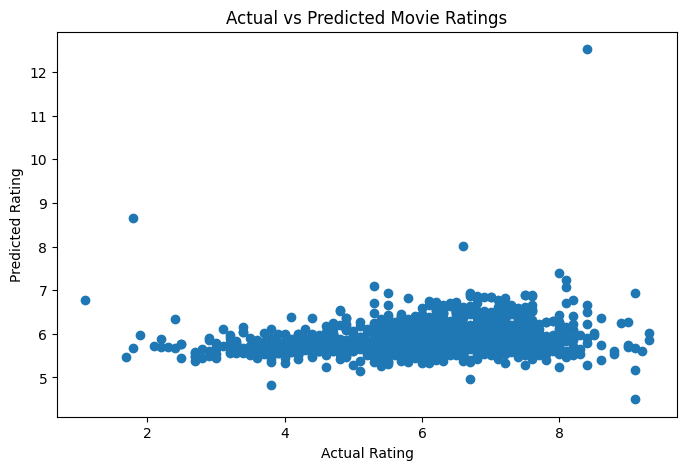

In [6]:
# ============================================================
# CODSOFT TASK 2 - MOVIE RATING PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload dataset
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(filename, encoding='latin1')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

# ------------------------------------------------------------
# Basic information
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------------------------
# Clean column names
# ------------------------------------------------------------

df.columns = df.columns.str.strip()

# Display columns
print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# Convert important columns to numeric
# ------------------------------------------------------------

if 'Rating' in df.columns:
    df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(
        df['Year'].astype(str).str.extract(r'(\d{4})')[0],
        errors='coerce'
    )

if 'Duration' in df.columns:
    df['Duration'] = pd.to_numeric(
        df['Duration'].astype(str).str.extract(r'(\d+)')[0],
        errors='coerce'
    )

# ------------------------------------------------------------
# Select useful features
# ------------------------------------------------------------

features = ['Year', 'Duration', 'Votes']

features = [col for col in features if col in df.columns]

print("\nFeatures used:", features)

# Convert Votes to numeric
if 'Votes' in df.columns:
    df['Votes'] = pd.to_numeric(
        df['Votes'].astype(str).str.replace(',', ''),
        errors='coerce'
    )

# Remove missing values
df_model = df[features + ['Rating']].dropna()

print("\nData after cleaning:", df_model.shape)

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# Linear Regression Model
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL RESULTS ==========")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# ------------------------------------------------------------
# Actual vs Predicted
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()